# CUPED — A/B Test Analysis

Uses pre-experiment revenue to reduce variance in a standard A/B test,
producing tighter confidence intervals without collecting more data.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [44]:
df = pd.read_csv(Path("../data/raw/ab_test.csv"))
df.head()

,user_id,treatment,pre_revenue,post_revenue
0,0,0,27.991816,26.171468
1,1,1,13.702447,6.483654
2,2,0,17.535469,80.336287
3,3,1,36.958760,85.921837
4,4,1,6.383704,4.677226


In [45]:
TREATMENT = 'treatment'   # binary assignment: 1 = saw new feature, 0 = control
OUTCOME   = 'post_revenue'  # revenue per user during the experiment period

In [46]:
# Sanity check: pre_revenue means should be nearly identical between groups
# (randomisation worked) while post_revenue means should differ by ~$2 (the treatment effect)
df.groupby(TREATMENT)[['pre_revenue', OUTCOME]].describe().T

treatment                     0            1
pre_revenue  count  4991.000000  5009.000000
             mean     31.192117    31.982554
             std      39.681986    38.354077
             min       0.615932     0.755810
             25%      10.589019    10.606345
             50%      20.052827    20.252894
             75%      36.555778    38.263421
             max     865.304336   476.152075
post_revenue count  4991.000000  5009.000000
             mean     31.193466    33.512629
             std      38.718769    38.011198
             min       0.369045     2.877383
             25%      10.401560    12.275307
             50%      19.665786    21.978275
             75%      36.573139    40.217185
             max     520.360763   633.146441

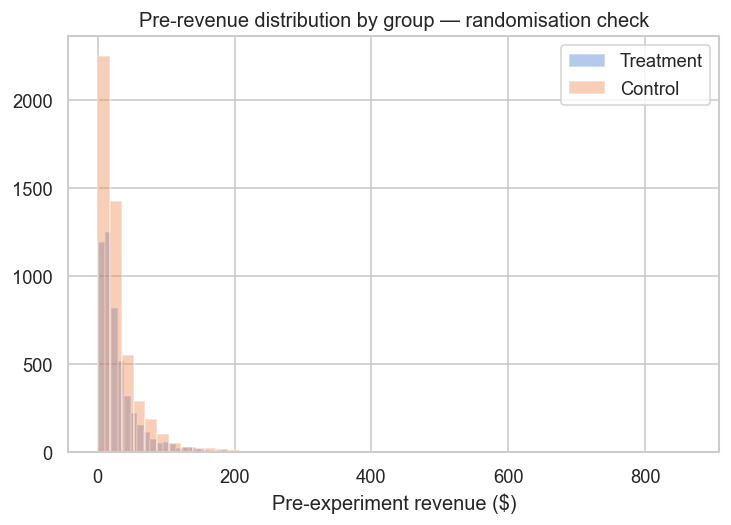

In [47]:
# Visualise pre_revenue distributions by group — should overlap almost perfectly
# if randomisation was successful. Any separation here would indicate a flawed experiment.
fig, ax = plt.subplots(figsize=(7, 4.5))

df[df[TREATMENT] == 1]['pre_revenue'].hist(ax=ax, bins=50, alpha=0.4, label='Treatment')
df[df[TREATMENT] == 0]['pre_revenue'].hist(ax=ax, bins=50, alpha=0.4, label='Control')
ax.set_xlabel("Pre-experiment revenue ($)")
ax.set_title("Pre-revenue distribution by group — randomisation check")
ax.legend()
plt.show()

In [52]:
# --- Naive ATT: standard difference-in-means ---
# This is the baseline estimate — no adjustment for pre-experiment data.
# The CI will be wide because post_revenue is highly variable across users.
treated = df[df[TREATMENT] == 1][OUTCOME]
control = df[df[TREATMENT] == 0][OUTCOME]

t_stat, p_val = stats.ttest_ind(treated, control)

att     = treated.mean() - control.mean()
se      = np.sqrt(treated.var() / len(treated) + control.var() / len(control))
ci_low  = att - 1.96 * se
ci_high = att + 1.96 * se

print(f"Naive ATT : ${att:.2f}")
print(f"95% CI    : [${ci_low:.2f}, ${ci_high:.2f}]  (width: ${ci_high - ci_low:.2f})")
print(f"p-value   : {p_val:.4f}")

Naive ATT : $2.32
95% CI    : [$0.82, $3.82]  (width: $3.01)
p-value   : 0.0025


In [53]:
# --- Compute theta (θ) ---
# θ = Cov(post_revenue, pre_revenue) / Var(pre_revenue)
# Interpretation: for every $1 a user spent above average before the experiment,
# we expect them to spend θ dollars above average during it — regardless of treatment.
# np.cov returns a 2x2 matrix; [0,1] picks the off-diagonal covariance term.
theta = np.cov(df['post_revenue'], df['pre_revenue'])[0, 1] / np.var(df['pre_revenue'])
print(f"θ = {theta:.4f}")

θ = 0.6115


In [54]:
# --- Apply CUPED adjustment ---
# Subtract the part of post_revenue that is predictable from pre_revenue.
# The mean-centering (pre_revenue - mean) ensures the adjustment averages to zero
# across all users, keeping the ATT estimate unbiased.
df['post_revenue_cuped'] = (
    df['post_revenue'] - theta * (df['pre_revenue'] - df['pre_revenue'].mean())
)

In [55]:
# --- CUPED ATT: same t-test, adjusted outcome ---
# The ATT estimate should stay close to the naive estimate (unbiased)
# but the CI should be narrower because user-level variance has been removed.
treated = df[df[TREATMENT] == 1]['post_revenue_cuped']
control = df[df[TREATMENT] == 0]['post_revenue_cuped']

t_stat, p_val = stats.ttest_ind(treated, control)

att     = treated.mean() - control.mean()
se      = np.sqrt(treated.var() / len(treated) + control.var() / len(control))
ci_low  = att - 1.96 * se
ci_high = att + 1.96 * se

print(f"CUPED ATT : ${att:.2f}")
print(f"95% CI    : [${ci_low:.2f}, ${ci_high:.2f}]  (width: ${ci_high - ci_low:.2f})")
print(f"p-value   : {p_val:.4f}")

CUPED ATT : $1.84
95% CI    : [$0.66, $3.01]  (width: $2.36)
p-value   : 0.0023


## compare the variance

In [56]:
var_naive = df['post_revenue'].var()
var_cuped = df['post_revenue_cuped'].var()
reduction = 1 - var_cuped / var_naive

print(f"Variance (naive) : {var_naive:.2f}")
print(f"Variance (CUPED) : {var_cuped:.2f}")
print(f"Variance reduction: {reduction:.1%}")
print(f"\nTheoretical reduction: {df['pre_revenue'].corr(df['post_revenue'])**2:.1%}")
print(f"(= pre/post correlation²)")

Variance (naive) : 1473.15
Variance (CUPED) : 903.88
Variance reduction: 38.6%

Theoretical reduction: 38.6%
(= pre/post correlation²)
